# 10 best hiscores from 10 walk with only ewkinos

In [1]:
folder = "../data/fake_ewkoff3/"
path = f"{folder}/all_hiscores/*dict"
truthfile = f'{folder}/truth.dict'
outfile = f"{folder}/hiscore.png"

In [2]:
import re
#import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import glob
import ast
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
import sys,os,copy,glob
import numpy as np
sys.path.append(os.path.abspath('../smodels'))
sys.path.append(os.path.abspath('../'))
from builder.protomodel import ProtoModel
from builder.manipulator import Manipulator
from tester.predictor import Predictor
from tester.combiner import Combiner
#from walker.hiscore import Hiscore
from smodels.experiment.databaseObj import Database
from smodels.base import runtime
from smodels.base.physicsUnits import fb
runtime._experimental = True
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from base.runEnviron import RunEnviron
from names import particleLabels
from sparticleNames import SParticleNames
# sns.set() #Set style
sns.set_style('ticks')
#sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=2.0)
# sns.set_palette(sns.color_palette("Paired"))
sns.set_palette(sns.color_palette("deep"))
#from smodels.tools import smodelsLogging
#smodelsLogging.setLogLevel('error')
environ=RunEnviron()

In [4]:
log_file = glob.glob(path)
print ( os.path.abspath ( log_file[0] ) )
log_file[:3]

/home/walten/git/protomodels/data/fake_ewkoff1/all_hiscores/hiscores133.dict


['../data/fake_ewkoff1//all_hiscores/hiscores133.dict',
 '../data/fake_ewkoff1//all_hiscores/hiscores143.dict',
 '../data/fake_ewkoff1//all_hiscores/hiscores103.dict']

In [5]:
#Set colors:
allPids = [1000022, 1000006, 1000001, 1000021, 1000012, 1000023, 
            1000013, 2000006, 1000011, 1000005, 1000014, 1000004, 1000015, 1000016, 1000024]
namer = SParticleNames ( susy = False )
colors = sns.color_palette('deep',n_colors=len(namer.xIDs))

#Replace default colors:
for pid in sorted(namer.xIDs.keys()):
    if not pid in allPids:
        allPids.append(pid)
colorDict = dict(zip(allPids,colors))
colorDict[1000002] = colorDict # masses[pid].append(np.nan)[1000001]
colorDict[1000003] = colorDict[1000001]
colorDict[1000004] = colorDict[1000001]

In [6]:
pTrue = None
with open ( truthfile, "rt" ) as f:
    pTrue = eval(f.read())

In [7]:
def fromDict(inputDict):   
    p = ProtoModel(walkerid=0,environ=environ)
    for key,v in inputDict.items():
        setattr(p,key,copy.deepcopy(v))
        
    return p

#Get highest score from each run:
protomodelsDict = {}
#for ff in log_file:
pList = []
for fname in log_file:
    with open(fname,'r') as f:
        tList = eval(f.read())
        #run = eval(os.path.basename(ff).replace('real','').replace('.dict',''))
        tmp = [fromDict(pDict) for pDict in tList[:]]
        pList += tmp
p = sorted(pList, key = lambda p: p.K, reverse=True)
p=p[:10]
#protomodelsDict[run] = p  
p = [ fromDict ( pTrue ) ] + p 

In [8]:
for proto in p:
    walkerid = proto.walkerid
    step = proto.step
    print(walkerid,proto,'step=',step)

# Karr = np.array([p["K"] for p in protomodelsDict.values()])
Karr = np.array([proto.K for proto in p])
Kavg = Karr.mean()
Kstd = Karr.std()
Kmin = min ( Karr )
print( f'K (avg) = {Kavg:1.2f} +- {Kstd:1.2f} >= {Kmin:1.2f}' )

truth ProtoModel (X1Z,X2Z,X1W): K = 47.30, TL = 55.27 step= 0
103 ProtoModel (X1Z,Xt): K = 6.06, TL = 8.56 step= 418
111 ProtoModel (X1Z,Xt): K = 5.88, TL = 8.38 step= 300
103 ProtoModel (X1Z,Xt): K = 5.81, TL = 8.31 step= 420
102 ProtoModel (X1Z,Xt): K = 5.57, TL = 8.07 step= 415
144 ProtoModel (X1Z,Xt,Xc): K = 5.54, TL = 9.04 step= 1
103 ProtoModel (X1Z,Xtau,Xt): K = 5.06, TL = 8.56 step= 417
103 ProtoModel (X1Z,Xtau,Xt): K = 5.06, TL = 8.56 step= 415
141 ProtoModel (X1Z,Xt,X1W): K = 5.02, TL = 8.52 step= 1
111 ProtoModel (X1Z,Xt,Xnue): K = 4.89, TL = 8.39 step= 305
111 ProtoModel (X1Z,Xt,Xnue): K = 4.88, TL = 8.38 step= 303
K (avg) = 9.19 +- 12.06 >= 4.88


In [9]:
#Get all particles which appears in all models:
particles = []
analyses = []
#modelList = np.array(list(protomodelsDict.items()))
#runs = modelList[:,0]
#modelList = modelList[:,1]
for proto in p:
    particles += proto.unFrozenParticles()
    ana = proto.description.split(',')
    analyses += ana
    #print(analyses)
particles = list(set(particles))
analyses = sorted(list(set(analyses)))

#Build useful dataset:
walkerid_values = np.array([f"{proto.walkerid}:{proto.step}" for proto in p])
walkerid_values[0]="truth"
nparticles = np.array([len(proto.unFrozenParticles()) for proto in p])
Kvalues = np.array([proto.K if (proto.K and proto.K > 0) else 0.0 for proto in p])
TLvalues = np.array([proto.TL if (proto.TL and proto.TL > 0) else 0.0 for proto in p])
masses = dict([[pid,[]] for pid in particles])
for proto in p:
    for pid in masses:
        if pid in proto.masses:
            masses[pid].append(proto.masses[pid])
        else:
            masses[pid].append(-100.0)
for pid in masses:
    masses[pid] = np.array(masses[pid])
dataDict = {'walkerid': walkerid_values, 'K' : Kvalues, 'TL': TLvalues, 'nparticles' : nparticles}
dataDict.update(masses) 
bestCombo_values = np.array([proto.description for proto in p])
dataDict.update({"bestCombo":bestCombo_values}) 

df = pd.DataFrame(dataDict)

In [10]:
def standardizeK ( K, offset : float = 0. ):
    return ( K - Kmin ) / Kstd * 2.5 + offset

standardizedKs = list ( standardizeK ( df["K"] ) )

In [11]:
t_ymin, t_ymax = min(standardizedKs)-.8,max(standardizedKs)+2.2

In [12]:
ymin, ymax = 50., 600

saving to ../data/fake_ewkoff1//hiscore.png.png


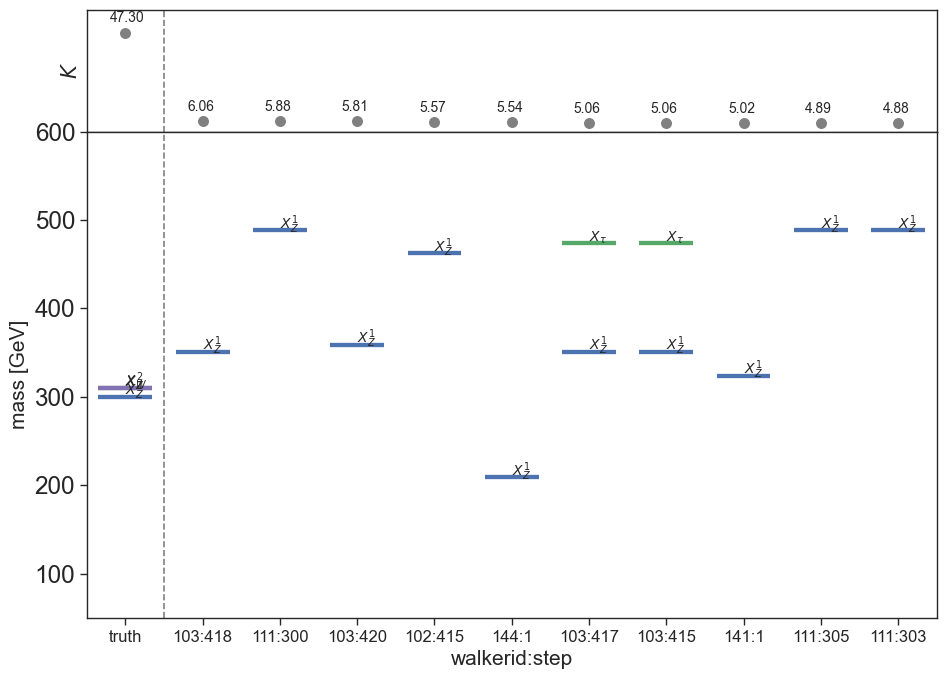

In [13]:
f, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[1, 4]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0)

nsteps = 10

pids = sorted(list(masses.keys()))

axarr[0].scatter(df['walkerid'],standardizedKs,s=50,c='gray')
#axarr[0].scatter(df['walkerid'],df['TL'],s=80,c='black')
axarr[0].set_ylabel(r'$K$', fontsize=15)
axarr[0].set_ylim( t_ymin, t_ymax )
axarr[0].set_yticks([])

for i,row in df.iterrows():
    index = np.where(walkerid_values == row['walkerid'])[0][0] 
    #print(index)
    if row['K'] == max(df['K']):        
        #axarr[0].annotate(r'$\mathbf{%1.2f}$' %row['K'],(index-0.2,row['K']-Kmin+0.5),
        #                  fontsize=10)
        axarr[0].annotate(rf'{row["K"]:1.2f}',(index-.2, standardizeK ( row["K"], 1)),fontsize=10)
    else:
        axarr[0].annotate(rf'{row["K"]:1.2f}',(index-.2, standardizeK (row['K'], 1)),fontsize=10)
        #axarr[0].annotate(r'$%1.2f$' %row['TL'],(index-0.2,row['TL']+0.5),fontsize=10)


for pid in pids:    
    data = df
    sns.scatterplot(x=data['walkerid'],y=data[pid], size=1000,sizes=(1500,1500),marker='_',
                    label=r'$%s$' %(particleLabels[pid]), legend=False,
                    c=[colorDict[pid]],ax=axarr[1])
    index = [np.where(walkerid_values == d['walkerid'])[0][0] for j,d in data.iterrows()]
    for i,m in enumerate(masses[pid]):   
        if m < 0: continue
        #print(particleLabels[pid])
        axarr[1].annotate(r'$%s$' %(particleLabels[pid]),(index[i],m+2),fontsize=10)
axarr[1].set_ylim(ymin,ymax)
axarr[1].set_xlabel('walkerid:step', fontsize=15)
axarr[1].set_ylabel('mass [GeV]', fontsize=15)
axarr[1].set_xticks(sorted(df['walkerid'].tolist()), labels =sorted(df['walkerid'].tolist()),  fontsize=12)
#plt.savefig('highScore_massesv1.pdf')
#axarr[1].text(-0.7,300,'truth',fontsize=15,horizontalalignment='center')
axarr[1].vlines(x=.5,ymin=ymin,ymax=ymax,linestyle='--',color='gray')
axarr[0].vlines(x=.5,ymin=t_ymin,ymax=t_ymax,linestyle='--',color='gray')
print ( f"saving to {outfile}.png" )
plt.savefig ( f"{outfile}.png" )
plt.show()

In [14]:
df = df[1:]
standardizedKs = list ( standardizeK ( df["K"] ) )

saving to combinations_../data/fake_ewkoff1//hiscore.combs.png.png


FileNotFoundError: [Errno 2] No such file or directory: 'combinations_../data/fake_ewkoff1//hiscore.combs.png.png'

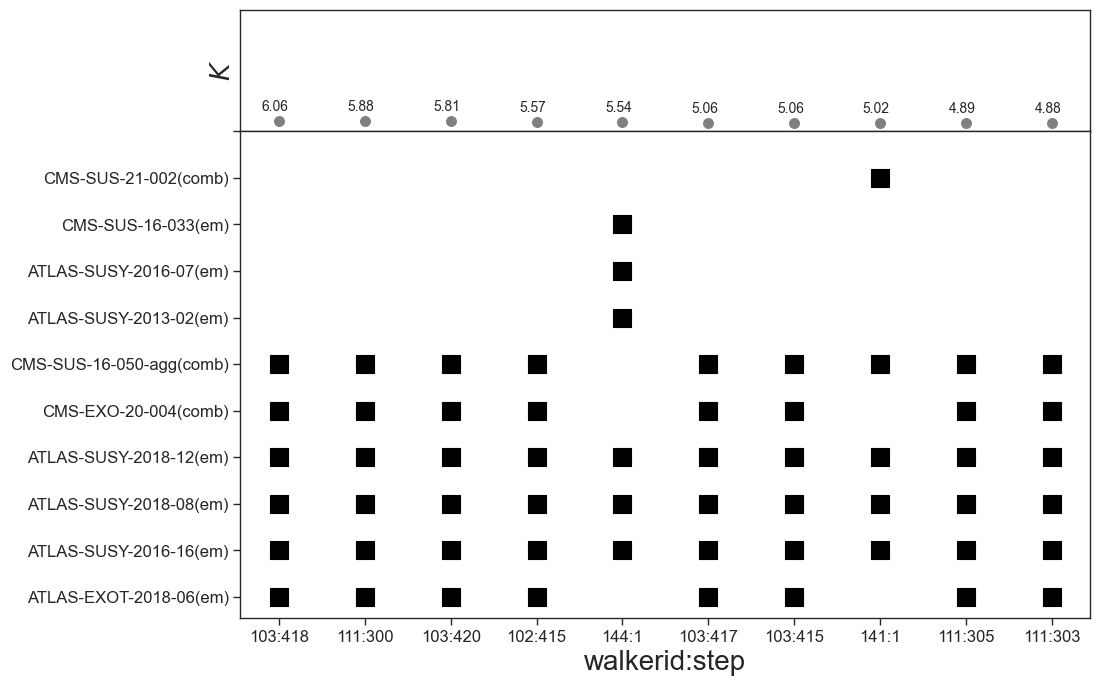

In [15]:
f, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[1, 4]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0)

nsteps = 10

pids = sorted(list(masses.keys()))

# axarr[0].scatter(df['walkerid'],df['K'],s=80,c='gray')
axarr[0].scatter(df['walkerid'],standardizedKs,s=50,c='gray')
#axarr[0].scatter(df['walkerid'],df['TL'],s=80,c='black')
axarr[0].set_ylabel(r'$K$')
axarr[0].set_ylim( t_ymin, t_ymax )
axarr[0].set_yticks([])
for i,row in df.iterrows():
    index = np.where(walkerid_values == row['walkerid'])[0][0] 
    # print(index)
    if row['K'] == max(df['K']):        
        #axarr[0].annotate(r'$\mathbf{%1.2f}$' %row['K'],(index-0.2,row['K']+0.5),
        #                  fontsize=10)
        axarr[0].annotate(rf'{row["K"]:1.2f}',(index-1-.2, standardizeK ( row["K"], 1)),fontsize=10)
        #axarr[0].annotate(r'$\mathbf{%1.2f}$' %row['TL'],(index-0.2,row['TL']+0.5),
        #                  fontsize=10)
    else:
        # axarr[0].annotate(r'$%1.2f$' %row['K'],(index-0.2,row['K']+0.5),fontsize=10)
        axarr[0].annotate(rf'{row["K"]:1.2f}',(index-1-.2, standardizeK (row['K'], 1)),fontsize=10)
        #axarr[0].annotate(r'$%1.2f$' %row['TL'],(index-0.2,row['TL']+0.5),fontsize=10)
    bC = sorted(row['bestCombo'].split(','))
    # print(bC)
    for j, b in enumerate(bC):
        axarr[1].scatter(row['walkerid'], b, c="black", marker='s', s=150)
        index2 = analyses.index(b)
        #axarr[1].annotate(f'{b}',(index-0.2,index2),fontsize=10)
axarr[1].set_xlabel('walkerid:step', fontsize=20)
axarr[1].set_ylabel('Analyses', fontsize=20)
axarr[1].set_ylabel('', fontsize=20)
axarr[1].set_xticks(sorted(df['walkerid'].tolist()), labels =sorted(df['walkerid'].tolist()),  fontsize=12)
axarr[1].set_yticks(analyses, labels =analyses,  fontsize=12)
fname = outfile.replace(".png",".combs.png")
print ( f"saving to combinations_{fname}.png" )
plt.savefig ( f"combinations_{fname}.png" )
plt.show()